<a href="https://colab.research.google.com/github/jerry124/Aprendizaje-Automatico/blob/main/Mis_Apuntes_Aprendizaje_Automatico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Mis Apuntes de Aprendizaje Automático

**Autor:** Gerardo Valdez Martínez  
**Curso:** Aprendizaje Automático  
**Repositorio:** Prácticas y proyectos de Machine Learning  

---

Estos apuntes los organicé como una guía personal para repasar los temas vistos en clase y en las prácticas.  
La idea no es hacer un documento demasiado formal, sino tener una explicación clara, entendible y útil para volver a consultar cuando esté trabajando con modelos de Machine Learning.

> Nota personal: este notebook resume lo que fui entendiendo de los ejercicios, principalmente en temas de regresión, vectorización, escalamiento, descenso del gradiente y uso de Scikit-Learn.


## 📚 Índice

1. ¿Qué es Machine Learning?  
2. Vectorización con NumPy  
3. Regresión lineal  
4. Función de costo  
5. Descenso del gradiente  
6. Learning rate  
7. Regresión lineal múltiple  
8. Escalamiento de variables  
9. Feature Engineering  
10. Regresión polinomial  
11. Uso de Scikit-Learn  
12. Métricas de evaluación  
13. Mini práctica integradora  
14. Conclusiones personales  


In [2]:
# ============================================================
# 📘 MIS APUNTES DE APRENDIZAJE AUTOMÁTICO
# ============================================================

# En este notebook voy dejando conceptos, ejemplos y observaciones
# que me ayudan a entender mejor los temas vistos en clase.

# Librerías base que usaré en algunos ejemplos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Librerías cargadas correctamente ✅")

Librerías cargadas correctamente ✅


# 1.  ¿Qué es Machine Learning?

Machine Learning, o Aprendizaje Automático, es una rama de la inteligencia artificial que permite que una computadora aprenda patrones a partir de datos.

En lugar de programar reglas exactas, se le dan ejemplos al modelo para que encuentre relaciones y después pueda hacer predicciones o clasificaciones.

## Ejemplo sencillo

Si tengo datos de casas, como:

- tamaño,
- número de habitaciones,
- ubicación,
- precio,

un modelo puede aprender la relación entre esas características y el precio para estimar el valor de una casa nueva.

## Observación personal

Algo que me quedó claro es que el modelo no “adivina”, sino que aprende a partir de patrones.  
Por eso la calidad de los datos importa muchísimo.


# 2. Vectorización con NumPy

La vectorización consiste en hacer operaciones matemáticas usando arreglos completos, sin tener que recorrer elemento por elemento con ciclos `for`.

Esto es muy importante porque en Machine Learning se trabaja con muchos datos y se necesita que las operaciones sean rápidas.


In [3]:
# Ejemplo sencillo de vectorización

a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

resultado = a + b

print("Vector a:", a)
print("Vector b:", b)
print("Resultado:", resultado)

Vector a: [1 2 3]
Vector b: [4 5 6]
Resultado: [5 7 9]


## Observación personal

Aquí entendí que NumPy ayuda a escribir código más limpio y rápido.  
En vez de hacer muchas operaciones una por una, se pueden hacer directamente sobre arreglos completos.


# 3. Regresión Lineal

La regresión lineal es uno de los modelos más básicos de Machine Learning.  
Sirve para predecir valores numéricos continuos.

Algunos ejemplos donde se puede usar:

- precio de una casa,
- precio de un automóvil,
- ventas,
- temperatura,
- consumo eléctrico.

La idea principal es encontrar una línea que se ajuste lo mejor posible a los datos.

## Fórmula básica

\[
y = mx + b
\]

Donde:

- \(x\) es la variable de entrada,
- \(y\) es la predicción,
- \(m\) es la pendiente,
- \(b\) es el intercepto.


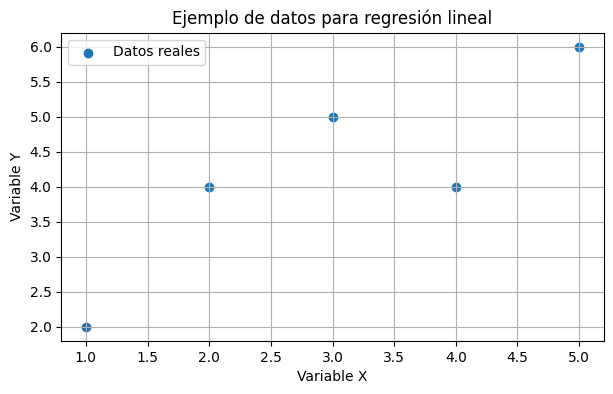

In [4]:
# Ejemplo visual de una relación lineal

x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 5, 4, 6])

plt.figure(figsize=(7, 4))
plt.scatter(x, y, label="Datos reales")
plt.xlabel("Variable X")
plt.ylabel("Variable Y")
plt.title("Ejemplo de datos para regresión lineal")
plt.legend()
plt.grid(True)
plt.show()

## Observación personal

La regresión lineal busca una relación simple entre las variables.  
Aunque es un modelo básico, sirve mucho para entender cómo funcionan otros modelos más avanzados.


# 4. Función de costo

La función de costo mide qué tan mal o bien está prediciendo el modelo.

En regresión se usa mucho el **error cuadrático medio**, porque penaliza más los errores grandes.

## Fórmula general

\[
J(w,b) = \frac{1}{2m}\sum_{i=1}^{m}(\hat{y}^{(i)} - y^{(i)})^2
\]

La idea es que el modelo ajuste sus parámetros para que este error sea lo más pequeño posible.


In [5]:
# Ejemplo pequeño de cálculo de error cuadrático medio

y_real = np.array([3, 5, 7, 9])
y_pred = np.array([2.5, 5.2, 6.8, 9.4])

mse = np.mean((y_real - y_pred) ** 2)

print("Valores reales:", y_real)
print("Predicciones:", y_pred)
print("MSE:", mse)

Valores reales: [3 5 7 9]
Predicciones: [2.5 5.2 6.8 9.4]
MSE: 0.12250000000000011


## Observación personal

Esta parte me ayudó a entender que entrenar un modelo realmente significa reducir el error.  
No se trata solo de que el código corra, sino de revisar si las predicciones se acercan a los valores reales.


# 5. Descenso del Gradiente

El descenso del gradiente es un método de optimización que permite ajustar los parámetros del modelo poco a poco para reducir el error.

El proceso general es:

1. El modelo hace una predicción.
2. Se calcula el error.
3. Se ajustan los parámetros.
4. Se repite muchas veces.

## Idea principal

\[
w := w - \alpha \frac{\partial J(w)}{\partial w}
\]

Donde \(\alpha\) representa el **learning rate**.


In [6]:
# Ejemplo conceptual: reducción de un valor usando pasos pequeños

valor = 10
learning_rate = 0.1

for i in range(10):
    valor = valor - learning_rate * valor
    print(f"Iteración {i+1}: {valor:.4f}")

Iteración 1: 9.0000
Iteración 2: 8.1000
Iteración 3: 7.2900
Iteración 4: 6.5610
Iteración 5: 5.9049
Iteración 6: 5.3144
Iteración 7: 4.7830
Iteración 8: 4.3047
Iteración 9: 3.8742
Iteración 10: 3.4868


## Observación personal

Aquí entendí que el modelo no encuentra la respuesta de golpe.  
Va ajustándose poco a poco, como si fuera bajando una pendiente hasta acercarse al menor error posible.


# 6. Learning Rate

El **learning rate** controla el tamaño de los pasos que da el modelo durante el aprendizaje.

Si el learning rate es muy alto, el modelo puede brincar demasiado y no converger.  
Si es muy bajo, el modelo puede tardar mucho en aprender.

## Resumen rápido

- Learning rate alto: puede ser inestable.
- Learning rate bajo: puede ser lento.
- Learning rate adecuado: ayuda a converger mejor.


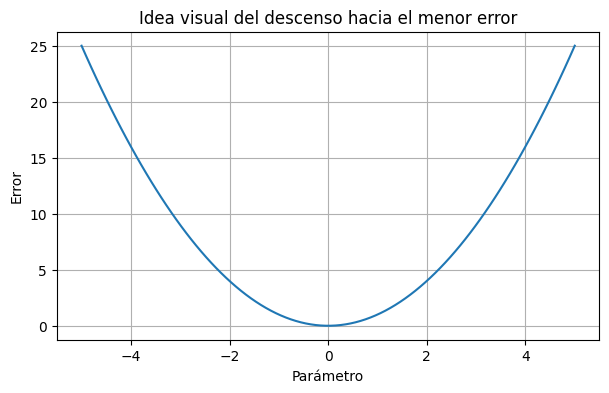

In [7]:
# Visualización sencilla de cómo cambia una función cuadrática

x_vals = np.linspace(-5, 5, 100)
y_vals = x_vals ** 2

plt.figure(figsize=(7, 4))
plt.plot(x_vals, y_vals)
plt.xlabel("Parámetro")
plt.ylabel("Error")
plt.title("Idea visual del descenso hacia el menor error")
plt.grid(True)
plt.show()

# 7. Regresión Lineal Múltiple

La regresión lineal múltiple se usa cuando hay más de una variable de entrada.

Por ejemplo, para predecir el precio de un automóvil podrían usarse variables como:

- tamaño del motor,
- peso,
- potencia,
- consumo,
- tipo de combustible.

## Fórmula general

\[
y = w_1x_1 + w_2x_2 + w_3x_3 + ... + b
\]

Aquí el modelo aprende un peso para cada variable.


In [8]:
# Ejemplo de datos con varias variables

datos = pd.DataFrame({
    "tamano_motor": [100, 130, 160, 200],
    "peso": [900, 1100, 1300, 1500],
    "potencia": [80, 100, 130, 160],
    "precio": [120000, 160000, 210000, 280000]
})

datos

,tamano_motor,peso,potencia,precio
0,100,900,80,120000
1,130,1100,100,160000
2,160,1300,130,210000
3,200,1500,160,280000


## Observación personal

En este punto entendí que un problema real casi nunca depende de una sola variable.  
Por eso la regresión múltiple es más cercana a situaciones reales.


# 8. Escalamiento de Variables

El escalamiento consiste en llevar las variables a rangos similares.

Esto es importante porque algunas variables pueden tener valores muy grandes y otras muy pequeños.

Ejemplo:

- edad: 20
- salario: 50000

Si no se escalan, algunas variables pueden influir demasiado en el entrenamiento.


In [9]:
from sklearn.preprocessing import StandardScaler

X = datos[["tamano_motor", "peso", "potencia"]]

scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)

pd.DataFrame(X_escalado, columns=X.columns)

,tamano_motor,peso,potencia
0,-1.283901,-1.341641,-1.237179
1,-0.473016,-0.447214,-0.577350
2,0.337869,0.447214,0.412393
3,1.419048,1.341641,1.402136


## Observación personal

Esta parte me pareció muy importante porque muchas veces el modelo no falla por el algoritmo, sino porque los datos no están bien preparados.

Escalar ayuda bastante cuando se usa descenso del gradiente o modelos sensibles a la escala.


# 9.  Feature Engineering

Feature Engineering significa crear, transformar o seleccionar variables para que el modelo pueda aprender mejor.

A veces no basta con meter los datos tal como vienen.  
También hay que pensar qué variables pueden representar mejor el problema.

## Ejemplos

- Crear variables polinomiales.
- Combinar columnas.
- Transformar variables.
- Eliminar columnas que no aportan.


In [10]:
# Ejemplo de creación de una nueva variable

datos["relacion_potencia_peso"] = datos["potencia"] / datos["peso"]

datos

,tamano_motor,peso,potencia,precio,relacion_potencia_peso
0,100,900,80,120000,0.088889
1,130,1100,100,160000,0.090909
2,160,1300,130,210000,0.100000
3,200,1500,160,280000,0.106667


## Observación personal

Aquí entendí que no todo depende del modelo.  
Una buena preparación de variables puede mejorar mucho los resultados.


# 10. Regresión Polinomial

La regresión polinomial permite modelar relaciones curvas.

La diferencia con la regresión lineal es que aquí se agregan potencias de las variables.

## Ejemplo

\[
y = b_0 + b_1x + b_2x^2
\]

Esto permite que el modelo se ajuste a patrones más complejos.


In [11]:
from sklearn.preprocessing import PolynomialFeatures

x = np.array([[1], [2], [3], [4], [5]])

poly = PolynomialFeatures(degree=2)
x_poly = poly.fit_transform(x)

pd.DataFrame(x_poly, columns=["1", "x", "x^2"])

,1,x,x^2
0,1.0,1.0,1.0
1,1.0,2.0,4.0
2,1.0,3.0,9.0
3,1.0,4.0,16.0
4,1.0,5.0,25.0


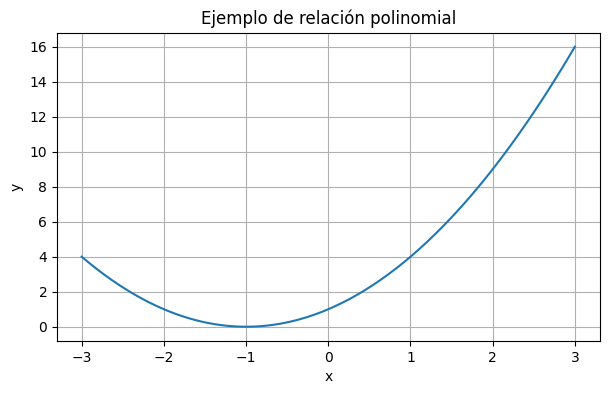

In [12]:
# Ejemplo visual de una curva polinomial

x_plot = np.linspace(-3, 3, 100)
y_plot = x_plot**2 + 2*x_plot + 1

plt.figure(figsize=(7, 4))
plt.plot(x_plot, y_plot)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Ejemplo de relación polinomial")
plt.grid(True)
plt.show()

## Observación personal

La regresión polinomial puede mejorar el ajuste cuando la relación no es recta.  
Pero también hay que tener cuidado, porque si el grado es muy alto puede aparecer sobreajuste.


# 11. Uso de Scikit-Learn

Scikit-Learn facilita mucho el trabajo porque ya incluye modelos, herramientas de preprocesamiento y métricas.

El flujo básico normalmente es:

1. Separar variables de entrada y salida.
2. Dividir datos en entrenamiento y prueba.
3. Crear el modelo.
4. Entrenar.
5. Predecir.
6. Evaluar.


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = datos[["tamano_motor", "peso", "potencia"]]
y = datos["precio"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

modelo = LinearRegression()
modelo.fit(X_train, y_train)

predicciones = modelo.predict(X_test)

print("Predicciones:", predicciones)

Predicciones: [160039.92015968]


# 12.  Métricas de Evaluación

Las métricas sirven para saber qué tan bien está funcionando un modelo.

Las más usadas en regresión son:

## MAE

Mide el error promedio absoluto.

## MSE

Penaliza más los errores grandes.

## R²

Indica qué tanto explica el modelo la variabilidad de los datos.

Un R² más alto generalmente indica un mejor ajuste, aunque siempre debe interpretarse junto con otras métricas.


In [14]:
mae = mean_absolute_error(y_test, predicciones)
mse = mean_squared_error(y_test, predicciones)
r2 = r2_score(y_test, predicciones)

print("MAE:", mae)
print("MSE:", mse)
print("R²:", r2)

MAE: 39.920159680681536
MSE: 1593.6191489311118
R²: nan


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


## Observación personal

Aquí entendí que no basta con decir “el modelo funciona”.  
Hay que comprobarlo con métricas y también revisar si las predicciones tienen sentido.


# 13. 🧪 Mini práctica integradora

En esta sección hago un ejemplo pequeño donde se simulan datos, se entrena una regresión lineal y se visualizan las predicciones.

La idea es juntar varios pasos vistos anteriormente.


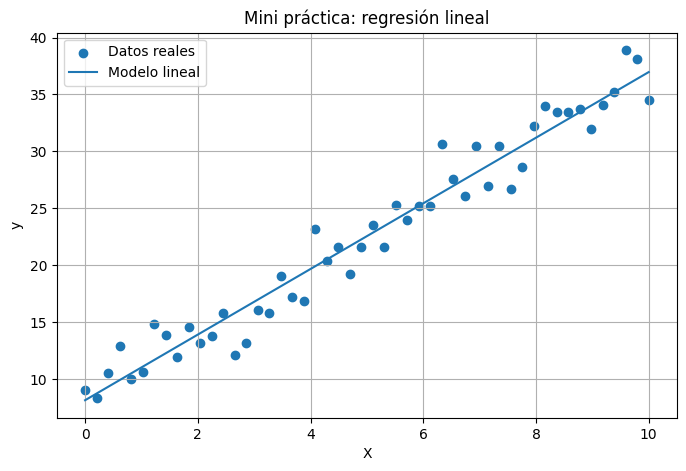

Pendiente aprendida: 2.8840332010163547
Intercepto aprendido: 8.128886184405948


In [15]:
# Simulación de datos sencillos para practicar

np.random.seed(42)

X = np.linspace(0, 10, 50).reshape(-1, 1)
y = 3 * X.ravel() + 8 + np.random.normal(0, 2, 50)

modelo = LinearRegression()
modelo.fit(X, y)

y_pred = modelo.predict(X)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, label="Datos reales")
plt.plot(X, y_pred, label="Modelo lineal")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Mini práctica: regresión lineal")
plt.legend()
plt.grid(True)
plt.show()

print("Pendiente aprendida:", modelo.coef_[0])
print("Intercepto aprendido:", modelo.intercept_)

## Interpretación

En la gráfica se puede observar cómo el modelo intenta ajustar una línea sobre los datos.

Aunque los puntos no caen exactamente sobre la línea, el modelo logra capturar la tendencia general.

Esto representa muy bien la idea de la regresión: no memorizar cada punto, sino encontrar una relación general.


# 14. 🚀 Conclusiones personales

Durante estas prácticas pude comprender mejor el flujo básico de un proyecto de Machine Learning.

Lo más importante que me llevo es:

- los datos deben revisarse antes de entrenar,
- el preprocesamiento puede cambiar mucho el resultado,
- el escalamiento ayuda en muchos modelos,
- las métricas permiten evaluar de forma más objetiva,
- y no siempre el modelo más complejo es el mejor.

También entendí que Machine Learning no es solo aplicar código, sino interpretar qué está pasando con los datos y con el modelo.



---

**Fin de mis apuntes.**
